# Lab 12 (Week 3 — Lab 2): Building Models with TensorFlow/Keras

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

Welcome to Lab 12! In Lab 11, you built a neuron and a forward pass by hand with NumPy. Now you'll use Keras to build, train, evaluate, and save a real neural network.

**For detailed theory on the Sequential API, optimizers, and training arguments, see the Lab 12 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab continues with the Wine dataset from Lab 11, built directly into scikit-learn — no download needed.

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (142, 13)
Test set: (36, 13)


## Example 1: Building a Model with the Sequential API

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

In [3]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

Final training accuracy: 0.991150438785553
Final validation accuracy: 0.9655172228813171


## Example 3: Visualizing Training History

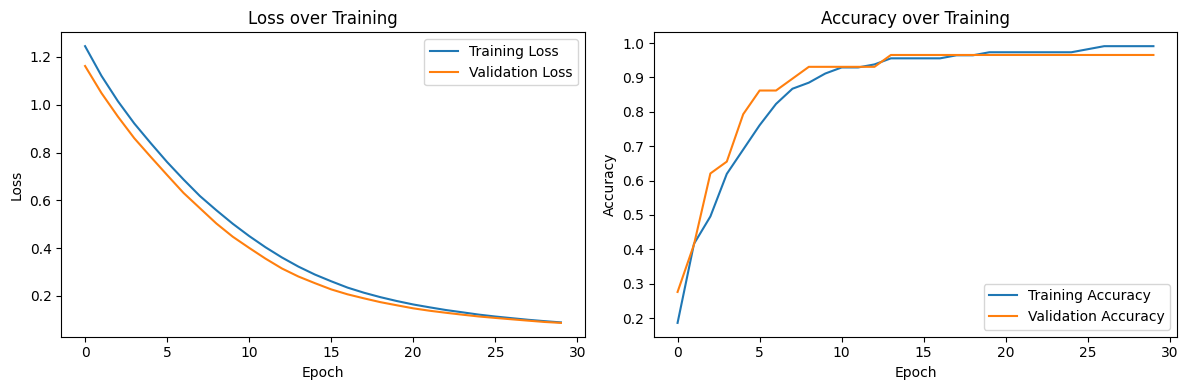

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training")

plt.tight_layout()
plt.show()

## Example 4: Evaluating and Predicting

In [5]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

predictions = model.predict(X_test_scaled, verbose=0)
predicted_classes = predictions.argmax(axis=1)
print("\nFirst 5 predicted classes:", predicted_classes[:5])
print("First 5 actual classes:    ", y_test[:5])

Test Loss: 0.0567
Test Accuracy: 1.0000

First 5 predicted classes: [0 0 2 0 1]
First 5 actual classes:     [0 0 2 0 1]


## Example 5: Saving and Loading the Model

In [6]:
model.save("wine_classifier.keras")
print("Model saved.")

loaded_model = keras.models.load_model("wine_classifier.keras")
loaded_loss, loaded_accuracy = loaded_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Reloaded model test accuracy:", loaded_accuracy)

Model saved.
Reloaded model test accuracy: 1.0


## Practice Exercise 1: Try a Different Optimizer

**Exercise:** Rebuild the same architecture from Example 1, but compile it with the `"sgd"` optimizer instead of `"adam"`. Train for 30 epochs and compare the test accuracy to Example 2's Adam version.

In [7]:
### YOUR CODE HERE ###
model_sgd = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model_sgd.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_sgd.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

test_loss_sgd, test_accuracy_sgd = model_sgd.evaluate(X_test_scaled, y_test, verbose=0)
### END ###

print("Test accuracy (SGD):", test_accuracy_sgd)

Test accuracy (SGD): 0.9722222089767456


### **SGD vs Adam Test Accuracies**

**Both Adam and SGD** optimizers achieved a **perfect test accuracy** of **1.0** on the Wine dataset. This is possible since the **Wine dataset is small** and **relatively easy and simple to classify**.

## Practice Exercise 2: Changing validation_split

**Exercise:** Retrain the original model (Adam optimizer) using `validation_split=0.3` instead of 0.2. Plot the new training/validation loss curves. Does the validation curve look different with less training data?

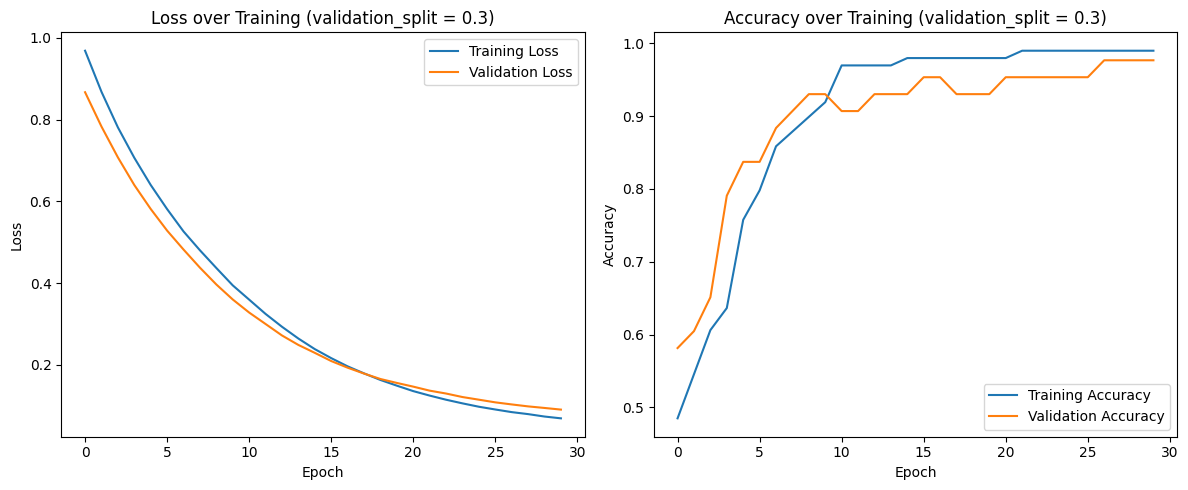

In [8]:
### YOUR CODE HERE ###
model_2 = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mod2_train_history = model_2.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.3,
    verbose=0
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod2_train_history.history["loss"], label="Training Loss")
plt.plot(mod2_train_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training (validation_split = 0.3)")

plt.subplot(1, 2, 2)
plt.plot(mod2_train_history.history["accuracy"], label="Training Accuracy")
plt.plot(mod2_train_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training (validation_split = 0.3)")

plt.tight_layout()
plt.show()
### END ###

### **Does the validation curve look different with less training data?**

The **validation curves do not look very different** since:

- **Both training and validation loss decrease smoothly** and **stay close to each other** in **both runs**.

- **Validation accuracy increases quickly** and **remains high** in **both cases**.

- There is **almost no** **overfitting** with either `validation_split=0.2` or `validation_split=0.3`.

On the small Wine dataset, **increasing** the **validation split** from **0.2** **to 0.3** **did not create much of a difference** between the **learning curves**.

## Practice Exercise 3: Predicting a New Sample After Reloading

**Exercise:** Using the `loaded_model` from Example 5, take one sample from `X_test_scaled` (any index), predict its class, and compare it against the true label in `y_test`.

In [15]:
sample_index = 0

### YOUR CODE HERE ###
sample = X_test_scaled[sample_index:sample_index + 1]
prediction = loaded_model.predict(sample, verbose=0)
predicted_class = prediction.argmax(axis=1)[0]
### END ###

print("Predicted class:", predicted_class)
print("Actual class:", y_test[sample_index])

Predicted class: 0
Actual class: 0


### **Did the sample taken from `X_test_scaled` match the true label in `y_test`?**

The **predicted label matches** the **true label** in **y_test** as **both these labels** yield a value of **0**.

## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own Model**: Design your own architecture (choose the number of layers and neurons), compile it with any optimizer, and train it on the Wine dataset. Report the test accuracy.
2. **Optimizer Comparison**: Train the same architecture with `"adam"`, `"sgd"`, and `"rmsprop"` optimizers (keeping epochs and batch_size constant). Create a small comparison table of test accuracy for each.
3. **Training Curves & Overfitting Check**: Plot the training and validation loss/accuracy curves for your best model. In a markdown cell, state whether you see any signs of overfitting, and how you can tell.
4. **Save, Reload, and Verify**: Save your best model to a file. In a new code cell, reload it and confirm it gives the same test accuracy as before saving — this simulates using a model without retraining it.
5. **Reflection**: In a markdown cell, write 3-4 sentences comparing this Keras workflow to the manual NumPy implementation from Lab 11 — what does Keras handle for you automatically?

In [17]:
# Task 1
from tensorflow import keras
from tensorflow.keras import layers

numair_model = keras.Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

numair_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

train_history_numair = numair_model.fit(
    X_train_scaled, y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.3,
    verbose=0
)

test_loss_nm, test_accuracy_nm = numair_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test accuracy (RMSprop): {test_accuracy_nm:.4f}")

Test accuracy (RMSprop): 1.0000


In [18]:
# Task 2
import pandas as pd

def train_and_evaluate(optimizer_name):
    numair_model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(3, activation="softmax")
    ])

    numair_model.compile(
        optimizer=optimizer_name,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    numair_model.fit(
        X_train_scaled, y_train,
        epochs=40,
        batch_size=8,
        validation_split=0.3,
        verbose=0
    )

    loss_test_nm, test_accuracy_nm = numair_model.evaluate(X_test_scaled, y_test, verbose=0)
    return round(test_accuracy_nm, 4)

test_acc_results = {
    "Optimizer": ["adam", "sgd", "rmsprop"],
    "Test Accuracy": [
        train_and_evaluate("adam"),
        train_and_evaluate("sgd"),
        train_and_evaluate("rmsprop")
    ]
}

comparison_table_df = pd.DataFrame(test_acc_results)
print(comparison_table_df)

  Optimizer  Test Accuracy
0      adam            1.0
1       sgd            1.0
2   rmsprop            1.0


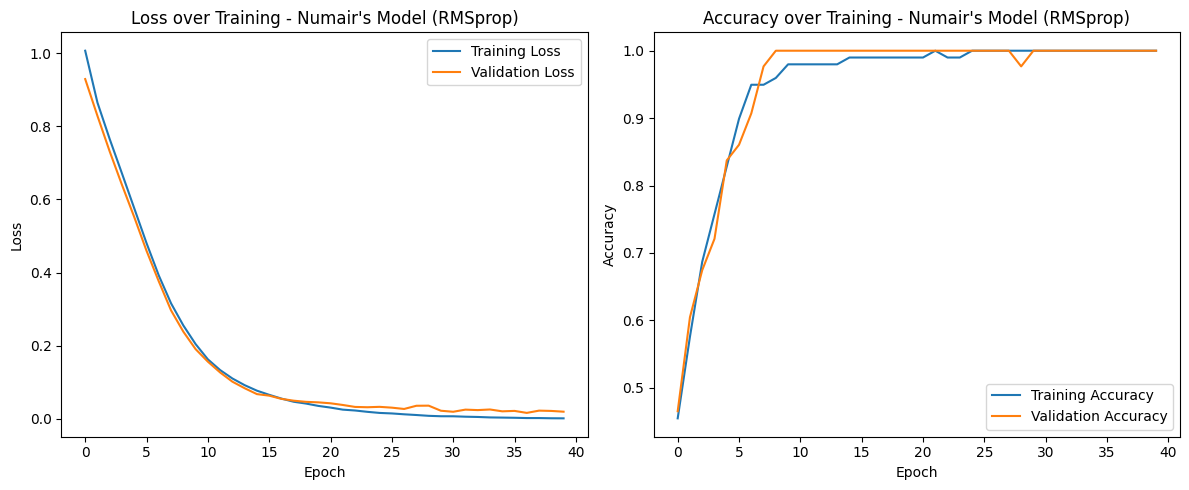

In [19]:
# Task 3
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_history_numair.history["loss"], label="Training Loss")
plt.plot(train_history_numair.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training - Numair's Model (RMSprop)")

plt.subplot(1, 2, 2)
plt.plot(train_history_numair.history["accuracy"], label="Training Accuracy")
plt.plot(train_history_numair.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training - Numair's Model (RMSprop)")

plt.tight_layout()
plt.show()

### **Are there any signs of overfitting from the above loss/accuracy curves?**

There are **no clear signs of overfitting** because:

- **Both the training** **and** **validation loss** **decrease together** and **stay very close throughout model training**.

- Similarly, **both training and validation accuracy** **increase quickly** and **remain almost the same** (**near 1.0**).

If the **model were overfitting**, the **validation loss** would have **begun increasing** while the **training loss continued to decrease**, which is **not the case here**.

In [21]:
# Task 4
numair_model.save("best_wine_model.keras")
print("best_wine_model.keras saved successfully!")

best_wine_model.keras saved successfully!


In [22]:
reloaded_nm = keras.models.load_model("best_wine_model.keras")
reloaded_loss_nm, reloaded_accuracy_nm = reloaded_nm.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Original test accuracy: {test_accuracy_nm:.4f}")
print(f"Reloaded test accuracy: {reloaded_accuracy_nm:.4f}")

Original test accuracy: 1.0000
Reloaded test accuracy: 1.0000


## **Task 5**

Compared to the manual NumPy implementation in Lab 11, **Keras** handles almost everything **automatically** and **internally**. It **performs** **forward propagation**, **calculates the loss**, **computes gradients through backpropagation**, and **updates all the weights for every batch automatically** without requiring to manually write a single line of gradient math. Instead, **only defining the architecture**, **selecting an appropriate optimizer and loss function**, and **calling `fit()`** are required. This makes **building and training neural networks more efficient** and **very less prone to errors**.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 129 (delta 60), reused 63 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 1.82 MiB | 23.05 MiB/s, done.
Resolving deltas: 100% (60/60), done.
